# Dawkins Weasel Program 
I first encountered this problem in high school, it's called Dawkins' weasel. It's a simple qualitative model of evolution (technically, artificial selection) which is meant to illustrate how selection and mutation on a gene sequence is far faster than blind random chance. Technically, this stretches the definition of qualitative model a little bit (qualitative models have to approximately reproduce some numerical data; this only reproduces the single fact that random chance is much slower than selection + mutation), but biologists will be biologists. This is in fact a simple example of an evolutionary algorithm, specifically a [(1, N) evolutionary strategy](https://direct.mit.edu/evco/article-abstract/1/1/1/1092/An-Overview-of-Evolutionary-Algorithms-for).

	
In high school, I coded this up as a simple exercise for my own understanding, then I searched for mathematical analyses on the net but failed to find any (I did not know yet about evolutionary algorithms). The closest I came was a [blog by a guy calling himself Dieben](https://dieben.blogspot.com/2009/08/dawkins-weasel-it-isnt-that-bad.html), which gives some graphs and some R code with German variable names but almost no explanations of how he got his results. I tried and failed to solve it myself, gave up on it for a while, and then picked it back up once my skills had increased. 

	
The basic setup is as follows: You want to reproduce a given text string of length $L$, the target (Dawkins used the Shakespeare quote "Methinks it is like a weasel"). The alphabet that the letters are drawn from has $A$ letters. Now, start with a random string. Generate $N$ copies (reproduction). In each resulting "offspring", "mutate" each letter with a given probability $\mu.$ Select the offspring that is closest to the target, distance being measured by the number of incorrect letters (Hamming distance), and repeat the preceding steps with the offspring in the place of the original random string. Keep doing this until you reach the target. The mathematical question is: what is the distribution of the number of steps it takes to reach the target? What is the analogous distribution for completely random mutation without selection? 


We can do the estimate for the completely random blind chance situation first, then simulate the problem, do some estimates of the mean, and build up the mathematical analysis in steps. 


Assume that each letter mutates independently, then this is a geometric distribution by definition. Since the alphabet has $A$ letters, the probability of choosing the correct letter by chance is $1/A.$ The probability that all $L$ characters are correct is thus $(1/A)^L.$ Since this is a geometric distribution, the mean number of steps to success is simply $A^L,$ or about $10^{40}$ steps for English letters. Now we simulate the evolutionary situation:

In [1]:
import numpy as np
from numba import vectorize, guvectorize, float64, int64
import time

#define variables
target = 'METHINKS IT IS LIKE A WEASEL'
alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ '
N_offspring = 100
mut_rate = 0.05
N_trials = 10000
L = len(target)
A = len(alphabet) 

#represent letters as numbers so we can use simple numpy arrays instead of character lists
alphabet_dict = {alphabet[i]: i for i in range(A)}
#reversed version of the previous, useful only if we want to print intermediate simulation results
alphabet_dict_rev = {i: alphabet[i] for i in range(A)}
#turn the target string into an array of numbers
target = np.array([alphabet_dict[target[i]] for i in range(L)])

#simulation, generating random 'offspring', mutating them, and keeping only the one closest to the target
#until after some number of steps all the characters of the best offspring become the same as the target.
#vectorize the function with numba to make it faster
#in order to print intermediate results, change N_trials to 1, comment out the guvectorize line
#and ".astype(float64)",
#and uncomment the print statement and the lines defining and returning the result array "res"
@guvectorize([(int64[:], int64, float64, int64[:], int64[:])], '(n),(),(),(p)->(p)', target='parallel', nopython=True)
def loop(target, N_offspring, mut_rate, trials, res):
    #res = np.zeros_like(trials)
    for k in trials:
        a = np.random.choice(A, L).astype(float64)
        count = 0
        max_distance = L
        while np.sum(a!=target) > 0:
            offspring = np.zeros((N_offspring, len(a)))
            offspring[:]=a
            random = np.random.random(size=(offspring.shape[0], offspring.shape[1]))
            mutations = np.random.choice(A, size=(offspring.shape[0], offspring.shape[1]))
            mutated = np.where(random < mut_rate*np.ones_like(random), mutations, offspring)
            distance = np.sum(mutated[:]!=target, axis=1)
            best_dist = np.min(distance)
            if best_dist <= max_distance:
                max_distance = best_dist
                a = mutated[np.argmin(distance)]
                count += 1
                #print("".join([alphabet_dict_rev[i] for i in a]))
        res[k]=count
    #return res

#call the function we just defined and time the run
trials = np.arange(N_trials)
empty1 = np.empty_like(trials)
start = time.time()
dist = loop(target, N_offspring, mut_rate, trials, empty1)
end = time.time()
print(str(end-start) + " sec")

107.30653786659241 sec


We can now estimate the mean number of steps under mutation and selection as follows: the initial number of correct letters is $L/A,$ since each character has a $1/A$ probability of being correct. The final number of correct letters must be $L.$ The average number of characters that mutate per step is $\mu \times L,$ and assuming all of these are correct (this is the selection assumption, we will see corrections to it later), we can solve the resulting equation $$\frac{L}{A} + \mu \times L \times l = L\$$ to get $\frac{1-1/A}{\mu}$ for the expected number of steps $l.$ This is compared to the simulation in the next cell. We will compare this to the numerical answer calculated with the full transition matrix later. For the same parameters as the previous setup, and a mutation probability of 0.05, we get about 20 steps. At least in the parameter regime where this approximation holds, this is already enough to show that artificial selection is astronomically faster than random chance, and that the algorithm runtime is constant considered as a function of L, but we must go further. (The implied number of correct characters per step is insanely small for random chance, of course.)

In [2]:
#find the (simulated) mean number of steps as a function of mutation rate, store it, and time it, 10 trials each point 
mean_range_mut = np.linspace(1e-5, .1)
means_simulated_mut = []
N_trials2 = 10
start2 = time.time()
for i in mean_range_mut:
    mean_dist = np.mean(loop(target, N_offspring, i, np.arange(N_trials2), np.empty_like(np.arange(N_trials2))))
    means_simulated_mut.append(mean_dist)

end2 = time.time()
print(str(end2-start2)+ " sec")

122.4783205986023 sec


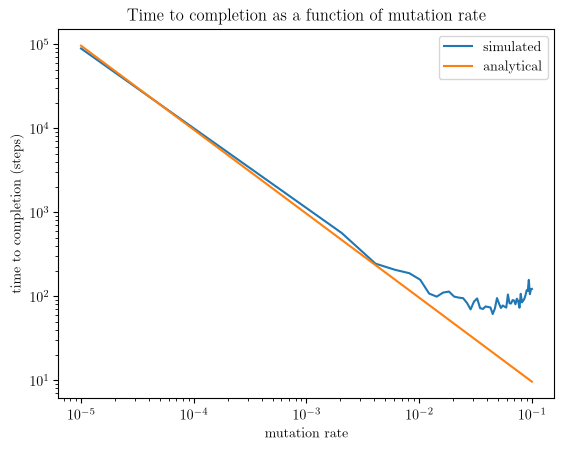

In [3]:
import matplotlib.pyplot as plt

#make plots look pretty 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    #"axes.linewidth": 2,
    #"xtick.labelsize": 16,
    #"ytick.labelsize": 16,
    #"axes.labelsize": 16,
    #"axes.titlesize": 20,
    #"legend.fontsize": 16,
    #"legend.edgecolor": 'white'
})

plt.figure(1)
plt.loglog(mean_range_mut, means_simulated_mut, label='simulated')
plt.loglog(mean_range_mut, (1-1/A)/mean_range_mut, label='analytical')
plt.xlabel("mutation rate")
plt.ylabel("time to completion (steps)")
plt.title("Time to completion as a function of mutation rate")
plt.legend()

We can now do the simplest case of not-completely-random evolution, and will build up to the general case. Assume we have a single letter that we want to evolve $(L=1).$ The state of the letter does not depend on the history of what happened before, it just depends on its current state, so this is a Markov chain. Since there are two states, correct and incorrect, the transition matrix is 2x2. 


The first entry in the transition matrix (the transition probability between the states 'incorrect' and 'incorrect') can be found as follows. There are two possibilities for what could happen: that the character does not mutate (probability $1-\mu$) or that it mutates and the resulting character is incorrect (probability $\mu (1-1/A)$). These are the only two possibilities, so we can just add them. The expression simplifies to $1-\mu/A.$ This quantity is called $p$ in the code.


We can then find the next entry in the matrix, the transition probability between the states 'incorrect' and 'correct'. The only possibility here is mutating and becoming correct, which has a probability of $\mu/A.$ As a sanity check, adding this to the previous entry results in 1, as expected.  


The third entry in the matrix is the transition probability from 'correct' to 'incorrect'. Rather like the second entry, there is only one possibility, that it mutates and becomes incorrect. The probability of this is $\mu (1-1/A),$ which is called $q$ in the code.


Finally, the last entry of the transition matrix is the probability from 'correct' to 'correct'.  Much like the first entry, there are two possibilities: either it stays the same or it mutates into the same character. The probability is then $1-\mu+\mu/A,$ which sums to 1 with the third entry.

The final transition matrix is 

$$\begin{bmatrix}
1-\mu/A & \mu/A \\
\mu (1-1/A) & 1-\mu+\mu/A
\end{bmatrix}.$$

Now we can move to the case of $L>1.$ All the characters are independent, so we can just take the tensor product of the separate 2x2 matrices for each character. However, there is a snag: this would give us a matrix of size $2^L.$ This is not what we want, because we want to consider only the probabilities of strings changing from Hamming distance $L,$ $L-1,$ etc from the target all the way to Hamming distance 0. Thus, our state space is of size $(L+1) \times (L+1)$ and we want a matrix of that size. We have to take some of the $2^L$ states and lump them together. It is also useful now to introduce the concept of `score', or L minus the Hamming distance. A string that is completely incorrect has a score of 0. 


Now, after the tensor product and lumping the new matrix elements are, with the indices starting from 0: $$a_{jk} = \sum_i \binom{L-j}{k-j+i} (1-p)^{k-j+i}p^{L-k-i}\binom{j}{i}q^i(1-q)^{j-i}$$ where the binomial coefficients come from the number of times the fundamental units are repeated. This formula was guessed by essentially writing down the product $(1-p)^ap^bq^c(1-q)^d$ and then figuring out what the powers should be by looking at examples of the lumped matrices generated with sympy. The binomial coefficients become 0 when their arguments are negative in this convention. 

In [4]:
from sympy import symbols, Matrix
from sympy.physics.quantum import TensorProduct

#unlumped analytical transition matrix, used to guess the form of the matrix elements
p = symbols('p')
q = symbols('q')

m = Matrix([[p, 1-p], [q, 1-q]])
m2 = TensorProduct(m, m)

m2

Matrix([
[p**2, p*(1 - p), p*(1 - p),      (1 - p)**2],
[ p*q, p*(1 - q), q*(1 - p), (1 - p)*(1 - q)],
[ p*q, q*(1 - p), p*(1 - q), (1 - p)*(1 - q)],
[q**2, q*(1 - q), q*(1 - q),      (1 - q)**2]])

In [5]:
from scipy.special import comb

#numerical transition matrix for n mutating characters
@vectorize([float64(float64, float64, float64, float64, float64)], forceobj=True)
def transition(L,j,k,p,q):
    i = np.arange(L+1)
    return np.sum(comb(L-j, k-j+i)*(1-p)**(k-j+i)*(p)**(L-k-i)*comb(j,i)*q**i*(1-q)**(j-i))

We can now use what we have learned to do the full problem. This is where the selection comes in. We have to create another transition matrix.
	

For the maximum score of all of the offspring to be 0, all the offspring have to have a score of 0. So, for the first column, which quantifies the probabilities of transitions to a maximum score of 0, just take the probabilities of the first column of the previous matrix describing mutations to the Nth power, since there are N offspring. For the second column, describing transitions to a maximum score of 1, we want all of the scores to be 0 or 1 but *not* all of them to be 0 so it's $(a_{0k}+a_{1k})^N-a_{0k}^N,$ where the $a_{jk}$ are elements of the previous matrix. For the next one the scores should be either 0, 1, or 2, but not all 1 or 0 so it's $(a_{0k}+a_{1k}+a_{2k})^N-(a_{0k}+a_{1k})^N,$ and it continues like that, each time subtracting the cumulative sum of previous entries in the row. The $a$ in each row sum to 1, so the rows of this new transition matrix also sum to 1, and this is still a valid transition matrix.


We can now use some results from Markov chain theory to find the distributions we are after. We have an absorbing chain (we can force it to be by making the entry in the lower right corner 1), so we can now use the 'discrete phase-type' distribution to calculate the time to absorption, or equivalently the time to completion of the process.


The CDF as a function of l, the number of steps, using Theorem 2.4.1 of Latouche and Ramaswami, Introduction to Matrix-Analytic Methods in Stochastic Modeling (1999), is $$P(l) = 1-\tau T^l \mathbf{1},$$ where $\tau$ is a vector of the right dimensions that has first entry 1 and the other entries 0 (the initial state of the chain), and $\mathbf{1}$ is a vector of all 1s. $T$ is the $L \times L$ square block of the transition matrix that does not include the 1 in the lower right corner. With the same symbols, the PDF is $\tau T^{l-1}T_0,$ where $T_0=(I-T)\mathbf{1}.$ The mean is $\tau (I-T)^{-1} \mathbf{1}.$

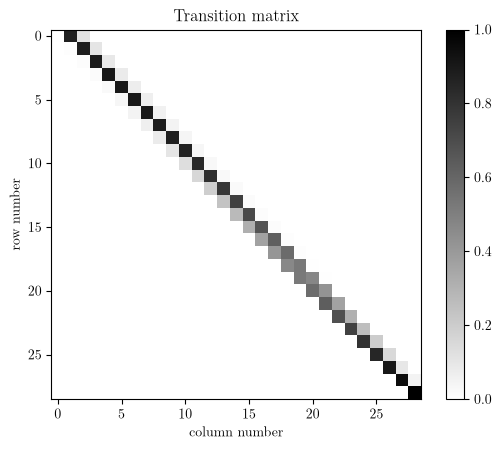

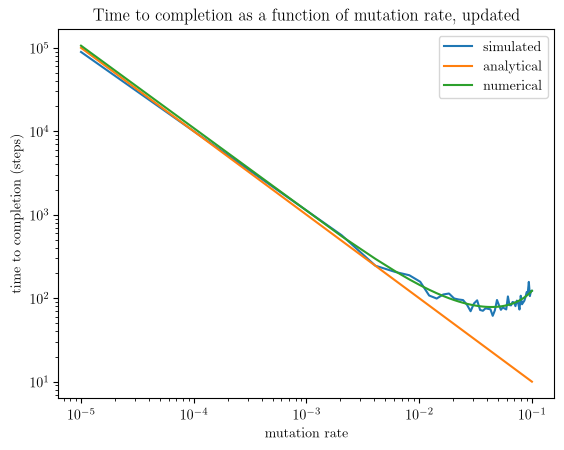

In [6]:
#create the full transition matrix for the maximum of n characters and look at it 
def transitionfull(L, N_offspring, mut_rate, len_alphabet):
    a = np.arange(L+1)
    p, q = 1-mut_rate/len_alphabet, mut_rate*(1-1/len_alphabet)
    A = transition(L,a[:,None],a,p,q) 
    B = np.cumsum(A, axis=1)**N_offspring 
    C = np.roll(B,1)
    C[:,0]=0
    D = B-C
    D[L]=0
    D[L,L]=1
    return D

D = transitionfull(L, N_offspring, mut_rate, A)
plt.figure(2)
plt.imshow(D, cmap='binary')
plt.xlabel("column number")
plt.ylabel("row number")
plt.title("Transition matrix")
plt.colorbar()

#initial distribution
def F(L):
    F = np.zeros(L)
    F[0]=1
    return F

#calculate the predicted distribution, both cdf and pdf
#able to capture the vast majority of the distribution's mass in an interval of length 4*int(mean) (steps)
mean = int(F(L)@np.linalg.solve(np.eye(L)-D[0:L,0:L], np.ones(L)))
pdf = np.array([F(L)@np.linalg.matrix_power(D[0:L,0:L],j)@((np.eye(L)-D[0:L,0:L])@np.ones(L)) for j in range(4*mean)])
cdf = np.array([1-F(L)@np.linalg.matrix_power(D[0:L,0:L],j)@np.ones(L) for j in range(1,4*mean)])

#calculate the predicted mean number of steps as a function of mutation rate
means_calculated_mut = []
for k in mean_range_mut:
    A = transitionfull(L, N_offspring, k, len(alphabet))
    mean_calc = F(L)@np.linalg.solve(np.eye(L)-A[0:L,0:L], np.ones(L))
    means_calculated_mut.append(mean_calc)

plt.figure(3)
plt.loglog(mean_range_mut, means_simulated_mut, label='simulated')
plt.loglog(mean_range_mut, 1/mean_range_mut, label='analytical')
plt.loglog(mean_range_mut, means_calculated_mut, label='numerical')
plt.xlabel("mutation rate")
plt.ylabel("time to completion (steps)")
plt.title("Time to completion as a function of mutation rate, updated")
plt.legend()

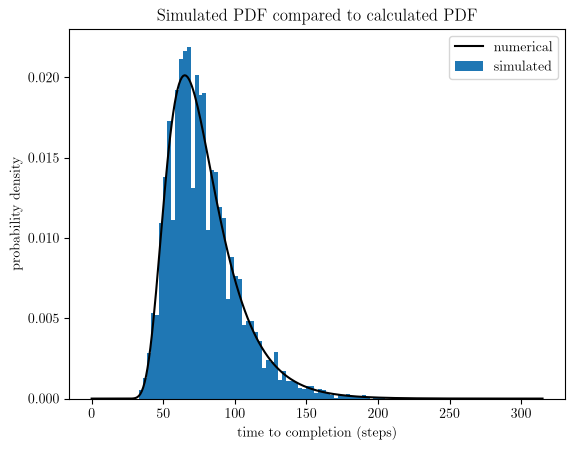

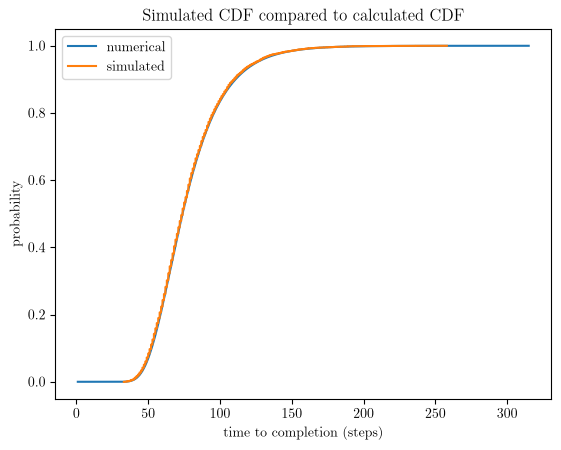

In [7]:
plt.figure(4)
plt.plot(np.arange(4*mean), pdf, label='numerical', color='black')
k, bins, patches = plt.hist(dist, density=True, bins='auto', label='simulated')
plt.xlabel("time to completion (steps)")
plt.ylabel("probability density")
plt.title("Simulated PDF compared to calculated PDF")
plt.legend()

plt.figure(5)
plt.plot(np.arange(1,4*mean), cdf, label='numerical')
#next 2 lines are two different ways of plotting the cumulative distribution, giving very similar results
plt.step(np.sort(dist), np.arange(len(dist))/(len(dist)-1), where='mid', label='simulated')
#plt.hist(dist, density=True, cumulative=True, bins='auto', label='simulation', histtype='step')
plt.xlabel("time to completion (steps)")
plt.ylabel("probability")
plt.title("Simulated CDF compared to calculated CDF")
plt.legend()